<a href="https://colab.research.google.com/github/rishike/machine_learning/blob/master/pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd

In [4]:
np.random.seed(23)

In [5]:
mu_vec1 = np.array([0,0,0])

In [6]:
cov_mat1 = np.array([[1,0,0], [0,1,0], [0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

In [7]:
df = pd.DataFrame(class1_sample, columns=['feature1', 'feature2', 'feature3'])

In [8]:
df['target'] = 1

In [9]:
mu_vec2 = np.array([1,1,1])

In [10]:
cov_mat2 = np.array([[1, 0, 0], [0, 1, 0], [0,0,1]])

In [11]:
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

In [12]:
df1 = pd.DataFrame(class2_sample, columns=['feature1', 'feature2', 'feature3'])

In [13]:
df1['target'] = 0

In [15]:
df = pd.concat([df, df1], ignore_index=True)

In [17]:
df = df.sample(40)
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [18]:
import plotly.express as px

In [20]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='feature3', color='target')
fig.update_traces(marker=dict(size=12), line=dict(width=2, color='DarkSlateGrey'), selector=dict(mode='markers'))
fig.show()

In [22]:
#step one - apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [23]:
df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

step 2 : Find a covariance matrix

In [24]:
covariance_matrix = np.cov([df.iloc[:, 0], df.iloc[:, 1], df.iloc[:,2]])

In [25]:
covariance_matrix

array([[1.02564103, 0.20478114, 0.080118  ],
       [0.20478114, 1.02564103, 0.19838882],
       [0.080118  , 0.19838882, 1.02564103]])

In [26]:
# step 3 : finding eigen and eigen values

In [29]:
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [30]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [31]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

In [32]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

In [33]:
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
        self._vert3d = (xs, ys, zs)

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = self._vert3d
        self.set_positions((xs[0],ys[0]),(xs3d[1],ys3d[1]))
        FancyArrowPatch.draw(self, renderer)

Text(0.5, 0, 'z_values')

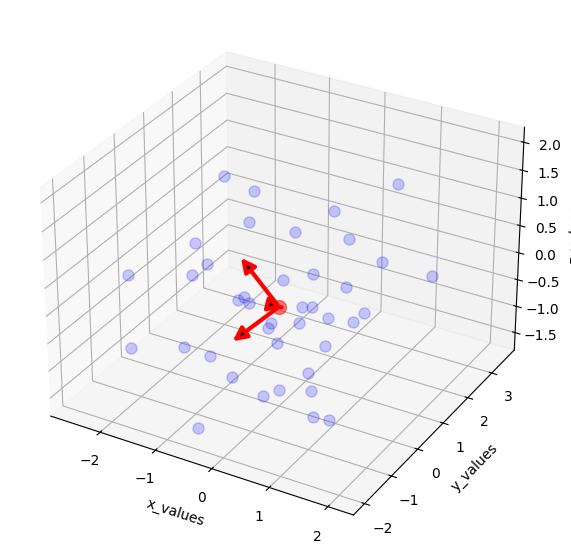

In [43]:
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d
import numpy as np

# Redefine Arrow3D with the missing do_3d_projection method
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs # Store the 3D vertices correctly

    def do_3d_projection(self, renderer=None):
        # Project the 3D points to 2D screen coordinates
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1])) # Update the 2D positions of the patch
        return np.min(zs) # Return z-order for correct rendering order

    def draw(self, renderer):
        # The parent draw method will now use the 2D positions set by do_3d_projection
        FancyArrowPatch.draw(self, renderer)

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([df['feature1'].mean()], [df['feature2'].mean()],[ df['feature3'].mean()], 'o', markersize=10, color='red', alpha=0.5)

for v in eigen_vectors.T:
    a = Arrow3D([df['feature1'].mean(), v[0]], [df['feature2'].mean(), v[1]], [df['feature3'].mean(), v[2]], mutation_scale=20, lw=3, arrowstyle="-|>",color='r')
    a.set_facecolor((0,0,0))
    ax.add_artist(a)
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

In [44]:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [45]:
transform_df = np.dot(df.iloc[:,0:3], pc.T)

new_df = pd.DataFrame(transform_df, columns=['PC1', 'PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


In [46]:
# 2d plot
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(new_df, x='PC1', y='PC2', color='target')
fig.update_traces(marker=dict(size=12), line=dict(width=2, color='DarkSlateGrey'), selector=dict(mode='markers'))
fig.show()